In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from brokenaxes import brokenaxes   # 需要先 pip install brokenaxes

In [112]:
from configparser import NoSectionError
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

def plot_Crick_test(
    MAE_data,
    title='',
    y_lim=None,
    ylabel='Titer error',
    xlabel='Model ID',
    color='#2F5D8A',
    highlight_best=True,
    save_path=None, figsize=(3.5, 2.7), yticks_interval=0.01):
    """
    更适合论文图的折线图版本
    """
    # 基础检查
    MAE_data = np.asarray(MAE_data, dtype=float)
    x = np.arange(1, len(MAE_data) + 1)

    # 风格：干净、克制
    sns.set_style("white")
    fig, ax = plt.subplots(figsize=figsize)

    # 主线
    ax.plot(
        x, MAE_data,
        color=color,
        linewidth=1.8,
        marker='o',
        markersize=4.8,
        markerfacecolor='white',
        markeredgecolor=color,
        markeredgewidth=1.2,
        zorder=3
    )

    # 高亮最优点（MAE越低越好）
    if highlight_best:
        best_idx = np.argmin(MAE_data)
        ax.scatter(
            x[best_idx], MAE_data[best_idx],
            s=42,
            facecolor=color,
            edgecolor='white',
            linewidth=0.8,
            zorder=4
        )
        # ax.annotate(
        #     f'Best: {MAE_data[best_idx]:.3f}',
        #     xy=(x[best_idx], MAE_data[best_idx]),
        #     xytext=(3, -12),
        #     textcoords='offset points',
        #     fontsize=8,
        #     ha='center',
        #     va='center'
        # )

    # 坐标轴标签
    ax.set_xlabel(xlabel, fontsize=10, labelpad=5)
    ax.set_ylabel(ylabel, fontsize=10, labelpad=5)

    # 标题不要太重
    ax.set_title(title, fontsize=10.5, pad=6)

    # x轴只显示整数
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xticks(x)

    # y轴范围
    if y_lim is not None:
        ax.set_ylim(y_lim)
    else:
        y_min, y_max = MAE_data.min(), MAE_data.max()
        margin = max((y_max - y_min) * 0.12, 0.03)
        ax.set_ylim(y_min - margin, y_max + margin)

    # y轴刻度更规整
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    # 细横线，尽量弱化
    ax.grid(
        axis='y',
        linestyle='-',
        linewidth=0.5,
        color='0.85',
        alpha=0.8
    )
    ax.grid(axis='x', visible=False)

    # Nature风格：只保留左、下坐标轴
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)

    # tick 样式
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        width=0.8,
        length=3
    )
    yticks = np.arange(y_lim[0], y_lim[1]+0.01, yticks_interval)
    ax.set_yticks(yticks)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=600, bbox_inches='tight')
    
    plt.show()

def plot_model_performance(models, mae, mse, pearson, spearman, r2=None,
                           y1_lim=(0,1), y2_lim=(0,1), save_path=None,
                           title=None):
    """
    绘制模型性能比较图（柱状图 + 折线图）
    参数：
        models: 模型名称列表
        mae, mse, pearson, spearman, r2: 对应的指标数值（list 或 None）
        title: 图标题
    """
    x = np.arange(len(models))
    width = 0.35

    colors = {
        'MAE': '#CBDEEE',
        'MSE': '#EBE6B5',
        'Pearson': '#666666',
        'Spearman': '#808080',
        # 'R2': '#A0A0A0'
    }

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax2 = ax1.twinx()

    # 样式调整
    for spine in ['top']:
        ax1.spines[spine].set_visible(False)
        ax2.spines[spine].set_visible(False)
    ax1.spines['left'].set_linewidth(0.8)
    ax1.spines['bottom'].set_linewidth(0.8)
    ax2.spines['right'].set_linewidth(0.8)
    ax2.spines['bottom'].set_linewidth(0.8)

    # 柱状图
    b1 = ax1.bar(x - width/2, mae, width, color=colors['MAE'], alpha=0.85, label='MAE')
    b2 = ax1.bar(x + width/2, mse, width, color=colors['MSE'], alpha=0.85, label='MSE')

    # 折线图
    l1, = ax2.plot(x, pearson, 'o-', color=colors['Pearson'], lw=1.5, markersize=5, label='Pearson')
    l2, = ax2.plot(x, spearman, 's-', color=colors['Spearman'], lw=1.5, markersize=5, label='Spearman')
    lines = [l1, l2]

    # R² 可能缺失
    if r2 is not None and len(r2) == len(models):
        l3, = ax2.plot(x, r2, 'd-', color=colors['R2'], lw=1.5, markersize=5, label='R²')
        lines.append(l3)

    # 柱上标数值
    for bars in [b1, b2]:
        for bar in bars:
            h = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.2f}',
                     ha='center', va='bottom', fontsize=9, color='#111827')

    # 轴标签和范围
    ax1.set_xlabel('model ID',fontsize=12)
    ax1.set_ylabel('Error (↓ better)', fontsize=12, color='#111827')
    ax2.set_ylabel('Correlation (r)', fontsize=12, color='#111827')
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, fontsize=10)
    ax1.set_ylim(y1_lim)
    ax2.set_ylim(y2_lim)
    ax1.tick_params(axis='both', labelsize=10)
    ax2.tick_params(axis='y', labelsize=10)
    ax1.grid(axis='x', visible=False)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    ax2.grid(False)

    # 动态图例
    legend_elements = [
        Patch(facecolor=colors['MAE'], label='MAE'),
        Patch(facecolor=colors['MSE'], label='MSE'),
        Line2D([0], [0], color=colors['Pearson'], marker='o', lw=1.8, label='Pearson'),
        Line2D([0], [0], color=colors['Spearman'], marker='s', lw=1.5, linestyle='--', label='Spearman')
    ]
    if r2 is not None and len(r2) == len(models):
        legend_elements.append(Line2D([0], [0], color=colors['R2'], marker='d', lw=1.5, linestyle='-.', label='R²'))

    fig.legend(handles=legend_elements,
               frameon=False, loc='upper center',
               bbox_to_anchor=(0.5, 1.05),
               ncol=5, fontsize=8)

    # ax1.set_title(title, fontsize=11, fontweight='bold', pad=12, color='#111827')
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, transparent=True, bbox_inches='tight')
    else:
        plt.show()


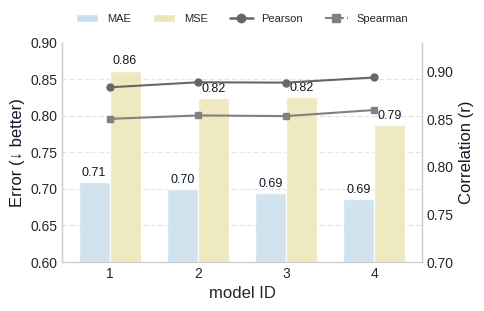

In [85]:
## external test set是41外推数据

models = ['1', '2', '3', '4']
internal_mae = [0.70929, 0.69890, 0.69425, 0.68559]
internal_mae_H1 = [0.67969,0.67515,0.67095, 0.67266]
internal_mae_H3 =[0.74360,0.72643,0.72126, 0.70056]

internal_mse = [0.86151, 0.82422, 0.82469, 0.78664]
internal_mse_H1 = [0.77107,0.75608,0.74007, 0.73073]
internal_mse_H3 = [0.96633,0.90318,0.92276, 0.85144]

internal_pearson = [0.88296, 0.88823, 0.88788, 0.89330]
internal_pearson_H1 = [0.86276,0.86632,0.86890, 0.87079]
internal_pearson_H3 = [0.84550,0.85520,0.85161, 0.86371]

internal_spearman = [0.84983, 0.85342, 0.85274, 0.85914]
internal_spearman_H1 = [0.69830,0.69732,0.69823, 0.70300]
internal_spearman_H3 = [0.85030,0.85969,0.85444, 0.86870]

internal_r2 = [0.72957, 0.74463, 0.73472, 0.73822]
internal_r2_H1 = [0.65928,0.68290,0.67391,0.66157]
internal_r2_H3 = [0.62138,0.65473,0.63563,0.65524]

plot_model_performance(models, internal_mae, internal_mse, internal_pearson, internal_spearman, 
y1_lim=(0.6, 0.9), y2_lim=(0.7, 0.93), save_path='../Figure/Fig.S1B1.svg')

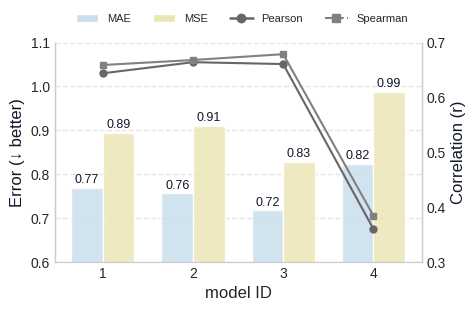

In [87]:
models = ['1', '2', '3', '4']
external_mae = [0.76865, 0.75578, 0.71668, 0.82245]
external_mae_H1 = [0.72998,0.72133, 0.71901, 0.77192]
external_mae_H3 =[0.81961,0.80117, 0.71360, 0.80065]

external_mse = [0.89290, 0.91008, 0.82823, 0.98647]
external_mse_H1 = [0.79066, 0.81495, 0.80677, 0.96705]
external_mse_H3 = [1.02765, 1.03545, 0.85651, 0.97809]

external_pearson = [0.64381, 0.66406, 0.66064, 0.35978]
external_pearson_H1 = [0.45547, 0.37505, 0.46391, 0.33973]
external_pearson_H3 = [0.31029, 0.47301, 0.40804, 0.60381]

external_spearman = [0.65893, 0.66804, 0.67867, 0.38391]
external_spearman_H1 = [0.50934, 0.41822, 0.48890, 0.36030]
external_spearman_H3 = [0.20044, 0.49293, 0.39264, 0.61300]

external_r2 = [-0.30842, 0.24345, -0.22310, -2.69173]
external_r2_H1 = [-1.75065, -0.77518, -0.83270, -1.39393]
external_r2_H3 = [-1.37202, -0.15531, -1.60926, -0.78105]

plot_model_performance(models, external_mae, external_mse, external_pearson, external_spearman, 
y1_lim=(0.6,1.1), y2_lim=(0.3,0.7), save_path='../Figure/Fig.S1B2.svg')

In [21]:
# Auto-sync with the two model-comparison cells above.
Crick_early_test = internal_mae.copy()
Crick_future_test = external_mae.copy()

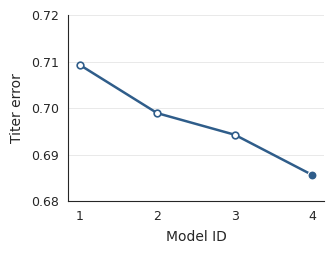

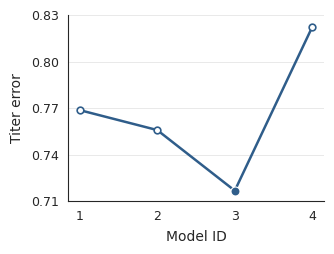

In [115]:
plot_Crick_test(Crick_early_test, y_lim=(0.68, 0.72))
plot_Crick_test(Crick_future_test, y_lim=(0.71, 0.83), yticks_interval=0.03)

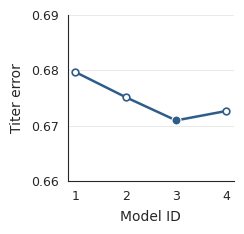

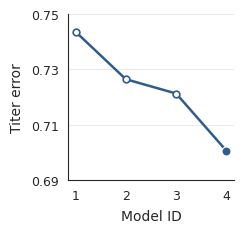

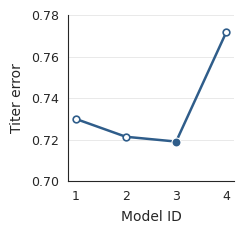

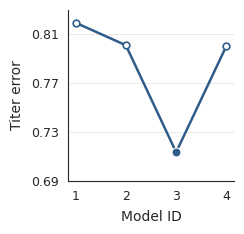

In [127]:
plot_Crick_test(internal_mae_H1, y_lim=(0.66,0.69), figsize=(2.6, 2.5))
plot_Crick_test(internal_mae_H3, y_lim=(0.69,0.75), figsize=(2.6, 2.5), yticks_interval=0.02)
plot_Crick_test(external_mae_H1, y_lim=(0.7,0.78), figsize=(2.6, 2.5), yticks_interval=0.02)
plot_Crick_test(external_mae_H3, y_lim=(0.69,0.83), figsize=(2.6, 2.5), yticks_interval=0.04)

# HA-only Checkpoint 推理

加载指定 checkpoint（`.pth`），在 `test.csv` 上做推理并导出预测结果。

In [ ]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# ===== 路径配置（按需修改）=====
REPO_ROOT = Path('/home/chenyh/workspace/fluProfiler')
CHECKPOINT_PATH = REPO_ROOT / 'runs/HA_only/split/HA/20260322_101738__HA_only_cached__pid908736/checkpoints/2026-03-22_21-21-28.pth'
CSV_PATH = REPO_ROOT / 'data/HA_only/split/test.csv'
EMBEDDING_ROOT = REPO_ROOT / 'data/reverse_test/embedding'
OUTPUT_PRED_CSV = REPO_ROOT / 'runs/HA_only/split/HA/20260322_101738__HA_only_cached__pid908736/test_predictions.csv'

BATCH_SIZE = 64
GPU_CACHE_GB = 28
DEVICE = 'cuda:2'  # 没有 GPU 可改成 'cpu'
ADD_SPECIAL_TOKEN = True

# 本地模块路径
sys.path.append(str(REPO_ROOT / 'src' / 'fluprofiler'))
sys.path.append(str(REPO_ROOT / 'experiments' / 'reverse_tests'))

from experiment_tools import GpuEmbeddingCache, convert_Pass2tensor, generate_matrix_on_device
from data.loaders import load_embedding
from evaluation.metrics import print_exams

print('checkpoint:', CHECKPOINT_PATH)
print('csv:', CSV_PATH)
print('embedding_root:', EMBEDDING_ROOT)

In [ ]:
class HAOnlyInferenceDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, add_special_token: bool = True):
        self.df = dataframe.reset_index(drop=True)
        self.emb_file_name_a = ('matrix_' + self.df['seq_id_a']).tolist()
        self.emb_file_name_c = ('matrix_' + self.df['seq_id_c']).tolist()
        if add_special_token:
            self.strainPassCats = convert_Pass2tensor(
                (
                    '<cls>'
                    + self.df['serumPassCat']
                    + '<eos>'
                    + self.df['virusPassCat']
                    + '<eos>'
                ).tolist()
            )
        else:
            self.strainPassCats = convert_Pass2tensor(
                (self.df['serumPassCat'] + self.df['virusPassCat']).tolist()
            )
        self.labels = torch.tensor(self.df['label'].tolist(), dtype=torch.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return (
            self.emb_file_name_a[idx],
            self.emb_file_name_c[idx],
            self.strainPassCats[idx],
            self.labels[idx],
        )


from tqdm.auto import tqdm

def run_inference(model, dataloader, device, cache, show_progress=True):
    model.eval()
    preds, refs = [], []
    iterator = tqdm(dataloader, total=len(dataloader), desc="Inference") if show_progress else dataloader

    with torch.no_grad():
        for batch in iterator:
            emb_file_name_a, emb_file_name_c, strainPassCats, labels = batch
            matrices_a_list = [cache.get(key) for key in emb_file_name_a]
            matrices_c_list = [cache.get(key) for key in emb_file_name_c]
            matrixs_a, masks_a = generate_matrix_on_device(matrices_a_list, device=device)
            matrixs_c, masks_c = generate_matrix_on_device(matrices_c_list, device=device)
            strainPassCats = strainPassCats.to(device)
            labels = labels.to(device)

            logits, output = model(
                matrices_a=matrixs_a,
                matrices_c=matrixs_c,
                matrix_attention_masks_a=masks_a,
                matrix_attention_masks_c=masks_c,
                strainPassCats=strainPassCats,
                labels=None,
            )

            preds.extend(output.view(-1).tolist())
            refs.extend(labels.tolist())

    return refs, preds

In [ ]:
device = torch.device(DEVICE)

# 1) 读测试集
inference_df = pd.read_csv('/home/chenyh/workspace/fluProfiler_back3/data/processing/epistrains_h3n2/normalize/H3N2_HA_cluster99.csv')
print('test rows:', len(inference_df))

In [ ]:
inference_df = inference_df.iloc[int(len(inference_df)/2):,:]

In [ ]:
inference_df.columns = ['seq_id_a', 'seq_id_c', 'seq_a', 'seq_c', 'serumPassCat', 'virusPassCat', 'Type']
inference_df['label'] = 0

In [ ]:
# 2) 仅加载推理所需 embedding
sequence_names = pd.concat([inference_df['seq_id_a'], inference_df['seq_id_c']]).unique().tolist()
embedding_files = ['matrix_' + item + '.pt' for item in sequence_names]
emb_dict = load_embedding("/home/chenyh/workspace/fluProfiler_back3/workplace/dms_experiment/20260323meeting/embedding", files=embedding_files)

In [ ]:
max_cache_bytes = int(GPU_CACHE_GB * 1024**3)
gpu_cache = GpuEmbeddingCache(cpu_store=emb_dict, device=device, max_bytes=max_cache_bytes)

# 3) DataLoader
dataset = HAOnlyInferenceDataset(inference_df, add_special_token=ADD_SPECIAL_TOKEN)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
print('serum count', len(inference_df['seq_id_a'].unique()))
print('virus count', len(inference_df['seq_id_c'].unique()))

In [ ]:
# 4) 加载模型（该 checkpoint 为 torch.save(model, ...)，直接 torch.load）
model = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model.to(device)
model.eval()

# 5) 推理
refs, preds = run_inference(model, dataloader, device, gpu_cache)

# 6) 指标
mae, mse, pearson, spearman, r2 = print_exams(refs, preds, print_result=True)

# 7) 保存预测
out_df = inference_df.copy()
out_df['pred'] = preds
OUTPUT_PRED_CSV.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(OUTPUT_PRED_CSV, index=False)
print('saved:', OUTPUT_PRED_CSV)

# 8) 打印缓存统计
print(f"[cache] hits={gpu_cache.hits}, misses={gpu_cache.misses}, copied_GB={gpu_cache.copied_bytes/(1024**3):.2f}")